Train a neural network on a small amount of data, and calculate the sensitivity indices as if it were the true simulator with no misspecification or inaccuracy.

In [53]:
import numpy as np
import pandas as pd
import math
from scipy import stats
from sklearn.preprocessing import MinMaxScaler, PowerTransformer
import copy

import torch
import torch.nn as nn
import torch.optim as optim
from tqdm.notebook import tqdm

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

import matplotlib.pyplot as plt

from SALib.sample import saltelli
from SALib.analyze import sobol

In [2]:
plt.rcParams['figure.dpi'] = 200
plt.style.use('seaborn-v0_8-notebook')
plt.rc("font", 
       family="serif")
plt.rc("axes.spines", top=True, right=True)
# set explicit fontsizes for ticks, lables, legend and title
plt.rc('xtick', labelsize=16)
plt.rc('ytick', labelsize=16)
plt.rc('axes', labelsize=18)
plt.rc('legend', fontsize=12)
plt.rc('figure', titlesize=18)
# set gridlines and grid alpha and grid linestyle
plt.rc('axes', grid=True)
plt.rc('grid', linestyle='--')
plt.rc('grid', alpha=0.8)

In [22]:
class Borehole:
    def __init__(self, seed=42):
        self.rw_dist = stats.norm(loc=0.1, scale=0.0161812)
        self.r_dist = stats.lognorm(s=1.0056, scale=np.exp(7.71))
        self.Tu_dist = stats.uniform(63070, 115600)
        self.Hu_dist = stats.uniform(990, 1110)
        self.Tl_dist = stats.uniform(63.1, 116)
        self.Hl_dist = stats.uniform(700, 820)
        self.L_dist = stats.uniform(1120, 1680)
        self.Kw_dist = stats.uniform(9855, 12045)
        self.random_seed = seed

    def sample(self, n_samples=1000, return_np=False):
        """
        Borehole function: response is water flow through borehole in m^3 per year.

        Parameters:
        rw: radius of borehole in m
        r:  radius of influence in m
        Tu: transmissivity of upper aquifer in m^2/year
        Hu: potentiometric head of upper aquifer in m
        Tl: transmissivity of lower aquifer in m^2/year
        Hl: potentiometric head of lower aquifer in m
        Lth:  length of borehole in m
        Kw: hydraulic conductivity of borehole in m/year

        Use distribution objects defined in __init__ to sample n_samples from each parameter distribution. Then compute the water flow rate and return as a numpy array.
        """
        np.random.seed(self.random_seed)
        rw_samples = self.rw_dist.rvs(n_samples)
        r_samples = self.r_dist.rvs(n_samples)
        Tu_samples = self.Tu_dist.rvs(n_samples)
        Hu_samples = self.Hu_dist.rvs(n_samples)
        Tl_samples = self.Tl_dist.rvs(n_samples)
        Hl_samples = self.Hl_dist.rvs(n_samples)
        L_samples = self.L_dist.rvs(n_samples)
        Kw_samples = self.Kw_dist.rvs(n_samples)
        
        if return_np:
            input_data = np.column_stack((rw_samples, r_samples,
                                         Tu_samples, Hu_samples,
                                         Tl_samples,
                                         Hl_samples, L_samples,
                                         Kw_samples))
        else:
            input_data = np.core.records.fromarrays(
            [rw_samples, 
             r_samples, 
             Tu_samples, 
             Hu_samples, 
             Tl_samples,
             Hl_samples, 
             L_samples, 
             Kw_samples],
            names='r_w, r, T_u, H_u, T_l, H_l, L, K_w'
            )
        
        return input_data
    
    def scale_data(self, X):
        scaler = MinMaxScaler()
        data_array = np.array([X[name] for name in X.dtype.names]).T
        scaled_data = scaler.fit_transform(data_array)
        scaled_data = np.core.records.fromarrays(
        scaled_data_array.T, names=X.dtype.names
        )
        return scaled_data
    
    def evaluate1(self, X):
        """
        In the style of test functions from SALib, take in a
        numpy array with variables in specific order
        """
        n_samples = X.shape[0]
        Q = np.zeros(n_samples)
        for i in range(n_samples):
            numerator = 2 * math.pi * X['T_u'][i] * (X['H_u'][i] - X['H_l'][i])

            denom1 = np.log(X['r'][i] / X['r_w'][i])
            denom2 = 2 * X['L'][i] * X['T_u'][i] / (X['K_w'][i] * X['r'][i]**2)
            denom3 = X['T_u'][i] / X['T_l'][i]

            Q[i] = numerator / (denom1 * (1 + (denom2 / denom1) + denom3))

        return Q
    
    
    def evaluate2(self, X):
        """
        Pass in a regular numpy array instead of recarray in the following
        order of variables: ['r_w', 'r', 'T_u', 'H_u', 'T_l', 'H_l', 'L', 'K_w']
        """
        
        n_samples = X.shape[0]
        Q = np.zeros(n_samples)
        for i in range(n_samples):
            numerator = 2 * math.pi * X[i, 2] * (X[i, 3] - X[i, 5])

            denom1 = np.log(X[i, 1] / X[i, 0])
            denom2 = 2 * X[i, 6] * X[i, 2] / (X[i, 7] * X[i, 1]**2)
            denom3 = X[i, 2] / X[i, 4]

            Q[i] = numerator / (denom1 * (1 + (denom2 / denom1) + denom3))

        return Q

In [23]:
bh = Borehole(seed=47)
bh_inputs = bh.sample(500, return_np=True)

In [24]:
bh_inputs.shape

(500, 8)

In [25]:
bh_output = bh.evaluate2(bh_inputs)

In [26]:
bh_output.shape

(500,)

(array([ 13.,  60.,  87., 114.,  98.,  63.,  33.,  26.,   4.,   2.]),
 array([-42212.45386288, -22029.41655062,  -1846.37923836,  18336.6580739 ,
         38519.69538616,  58702.73269842,  78885.77001068,  99068.80732295,
        119251.84463521, 139434.88194747, 159617.91925973]),
 <BarContainer object of 10 artists>)

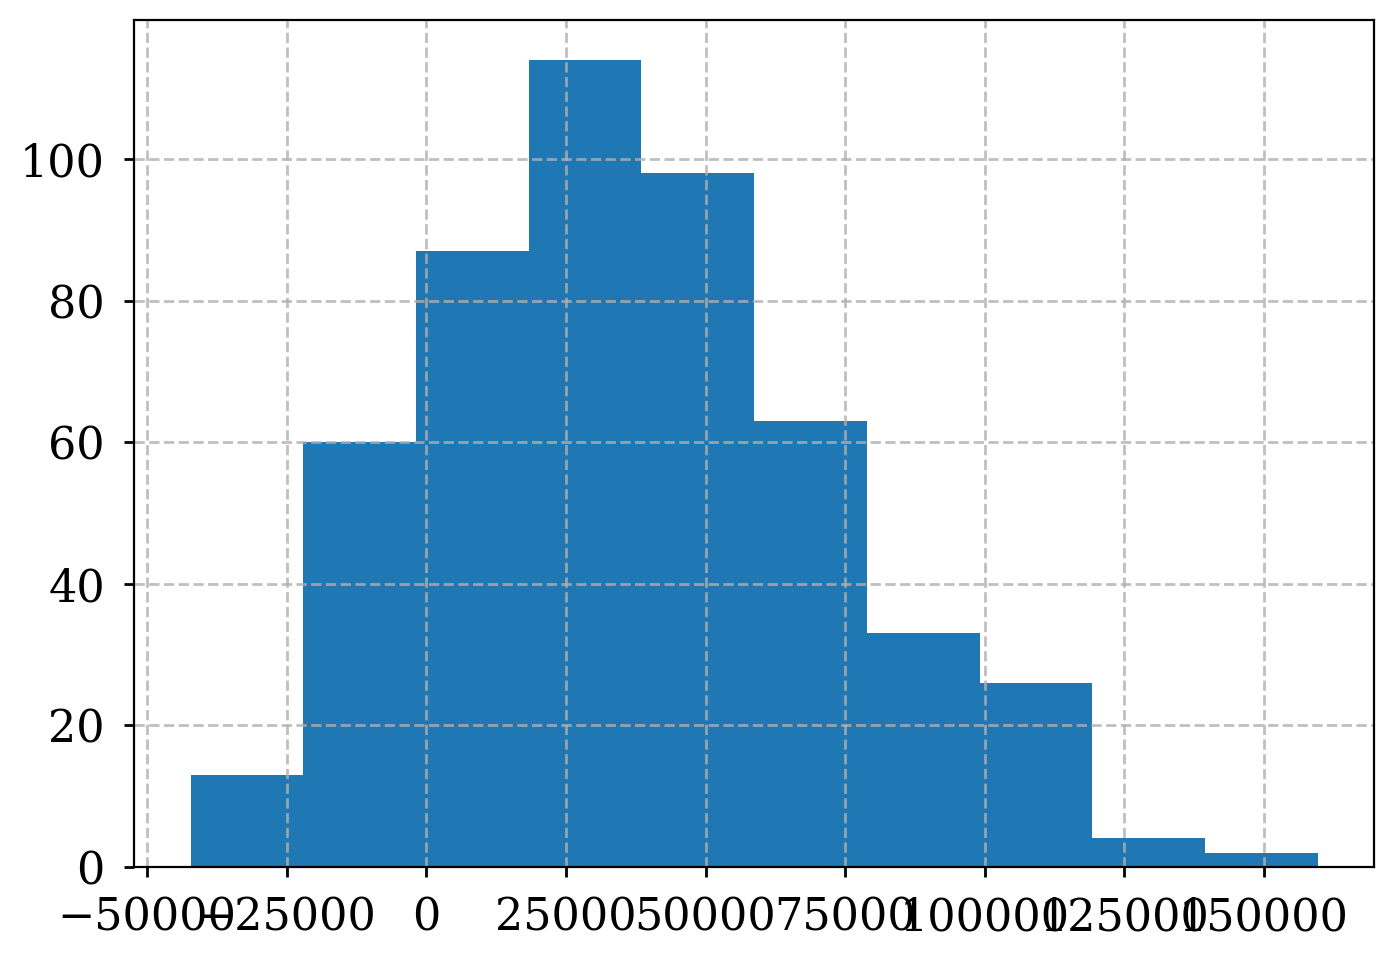

In [73]:
plt.hist(bh_output)

In [57]:
X_train_raw, X_test_raw, y_train_raw, y_test_raw = train_test_split(bh_inputs, bh_output, train_size=0.7, shuffle=True)
scaler = StandardScaler()
scaler.fit(X_train_raw)
X_train = scaler.transform(X_train_raw)
X_test = scaler.transform(X_test_raw)

scalerY = PowerTransformer()
scalerY.fit(y_train_raw.reshape(-1, 1))
y_train = scalerY.transform(y_train_raw.reshape(-1, 1))
y_test = scalerY.transform(y_test_raw.reshape(-1, 1))


X_train = torch.tensor(X_train, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.float32).reshape(-1, 1)
X_test = torch.tensor(X_test, dtype=torch.float32)
y_test = torch.tensor(y_test, dtype=torch.float32).reshape(-1, 1)

In [58]:
X_train.shape, y_train.shape, X_test.shape, y_test.shape

(torch.Size([350, 8]),
 torch.Size([350, 1]),
 torch.Size([150, 8]),
 torch.Size([150, 1]))

In [59]:
model = nn.Sequential(
    nn.Linear(8, 24),
    nn.ELU(),
    nn.Linear(24, 12),
    nn.ELU(),
    nn.Linear(12, 6),
    nn.ELU(),
    nn.Linear(6, 1)
)

In [60]:
loss_fn = nn.MSELoss()  # mean square error
optimizer = optim.Adam(model.parameters(), lr=1e-3)

In [61]:
n_epochs = 100   # number of epochs to run
batch_size = 10  # size of each batch
batch_start = torch.arange(0, len(X_train), batch_size)
 
# Hold the best model
best_mse = np.inf   # init to infinity
best_weights = None
history = []
 
for epoch in range(n_epochs):
    model.train()
    with tqdm(batch_start, unit="batch", mininterval=0, disable=True) as bar:
        bar.set_description(f"Epoch {epoch}")
        for start in bar:
            # take a batch
            X_batch = X_train[start:start+batch_size]
            y_batch = y_train[start:start+batch_size]
            # forward pass
            y_pred = model(X_batch)
            loss = loss_fn(y_pred, y_batch)
            # backward pass
            optimizer.zero_grad()
            loss.backward()
            # update weights
            optimizer.step()
            # print progress
            bar.set_postfix(mse=float(loss))
    # evaluate accuracy at end of each epoch
    model.eval()
    y_pred = model(X_test)
    mse = loss_fn(y_pred, y_test)
    mse = float(mse)
    history.append(mse)
    if mse < best_mse:
        best_mse = mse
        best_weights = copy.deepcopy(model.state_dict())

MSE: 0.01
RMSE: 0.10


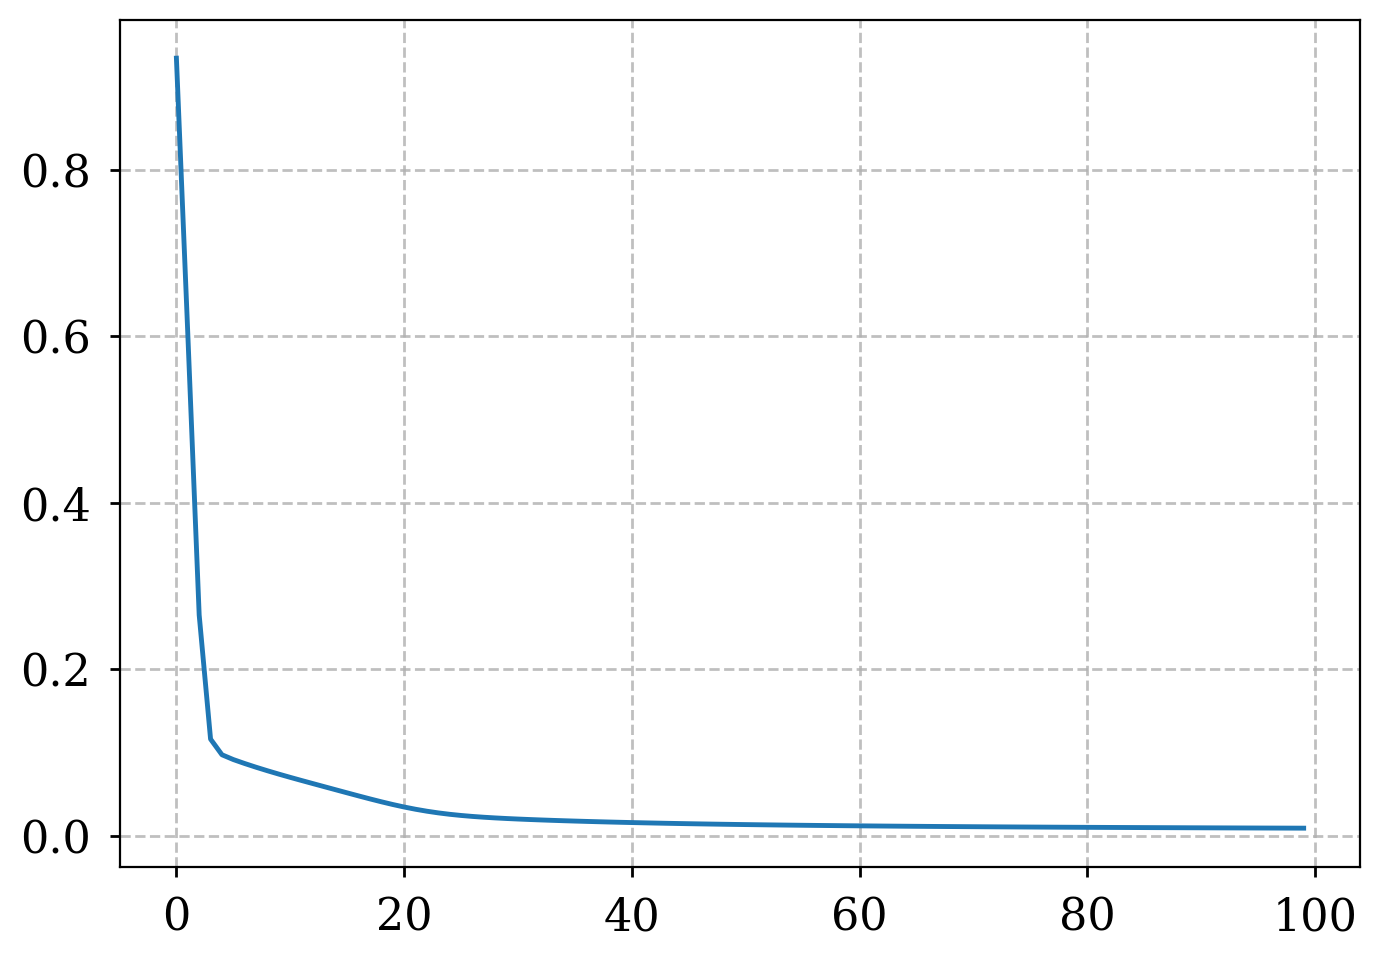

In [63]:
model.load_state_dict(best_weights)
print("MSE: %.2f" % best_mse)
print("RMSE: %.2f" % np.sqrt(best_mse))
plt.plot(history)
plt.show()

In [68]:
model.eval()
with torch.no_grad():
    for i in range(5):
        X_sample = X_test_raw[i:(i+1)]
        X_sample = scaler.transform(X_sample)
        X_sample = torch.tensor(X_sample, dtype=torch.float32)
        y_pred = model(X_sample)
        y_pred_us = scalerY.inverse_transform(y_pred[0].numpy().reshape(-1, 1))
        #         print(type(y_pred))
        print(f"X mapped to  {y_pred_us} (expected {y_test_raw[i]})")

X mapped to  [[-2737.9387]] (expected -1860.9049153934532)
X mapped to  [[54325.285]] (expected 54704.67223038033)
X mapped to  [[28337.828]] (expected 29484.679433902547)
X mapped to  [[-5142.731]] (expected -1016.8118816269438)
X mapped to  [[6552.497]] (expected 11448.62201610682)


Calculate Sensitivity Indices with this model

In [69]:
problem = {
    'num_vars': 8,
    'names': ['r_w', 'r', 'T_u', 'H_u', 'T_l', 'H_l', 'L', 'K_w'],
    'bounds': [[0.05, 0.15],
              [100, 50000],
              [63070, 115600],
              [990, 1110],
              [63.1, 116],
              [700, 820],
              [1120, 1680],
              [9855, 12045]]
}

In [70]:
param_values = saltelli.sample(problem, 2048)

/var/folders/0m/401pb5hj7y59vbxjhd49jjj80000gp/T/ipykernel_18693/2996815261.py:1: DeprecationWarning: `salib.sample.saltelli` will be removed in SALib 1.5. Please use `salib.sample.sobol`
  param_values = saltelli.sample(problem, 2048)


In [71]:
param_vals_scaled = torch.Tensor(scaler.transform(param_values))

In [79]:
Yscaled = model(param_vals_scaled)
Y_us = scalerY.inverse_transform(Yscaled.detach().numpy()).flatten()

In [80]:
Y_us.shape

(36864,)

(array([  69.,  781., 4013., 8294., 9986., 7931., 3987., 1415.,  343.,
          45.]),
 array([ 2240.9152832 ,  5447.36474609,  8653.81445312, 11860.26367188,
        15066.71289062, 18273.16210938, 21479.61132812, 24686.0625    ,
        27892.51171875, 31098.9609375 , 34305.41015625]),
 <BarContainer object of 10 artists>)

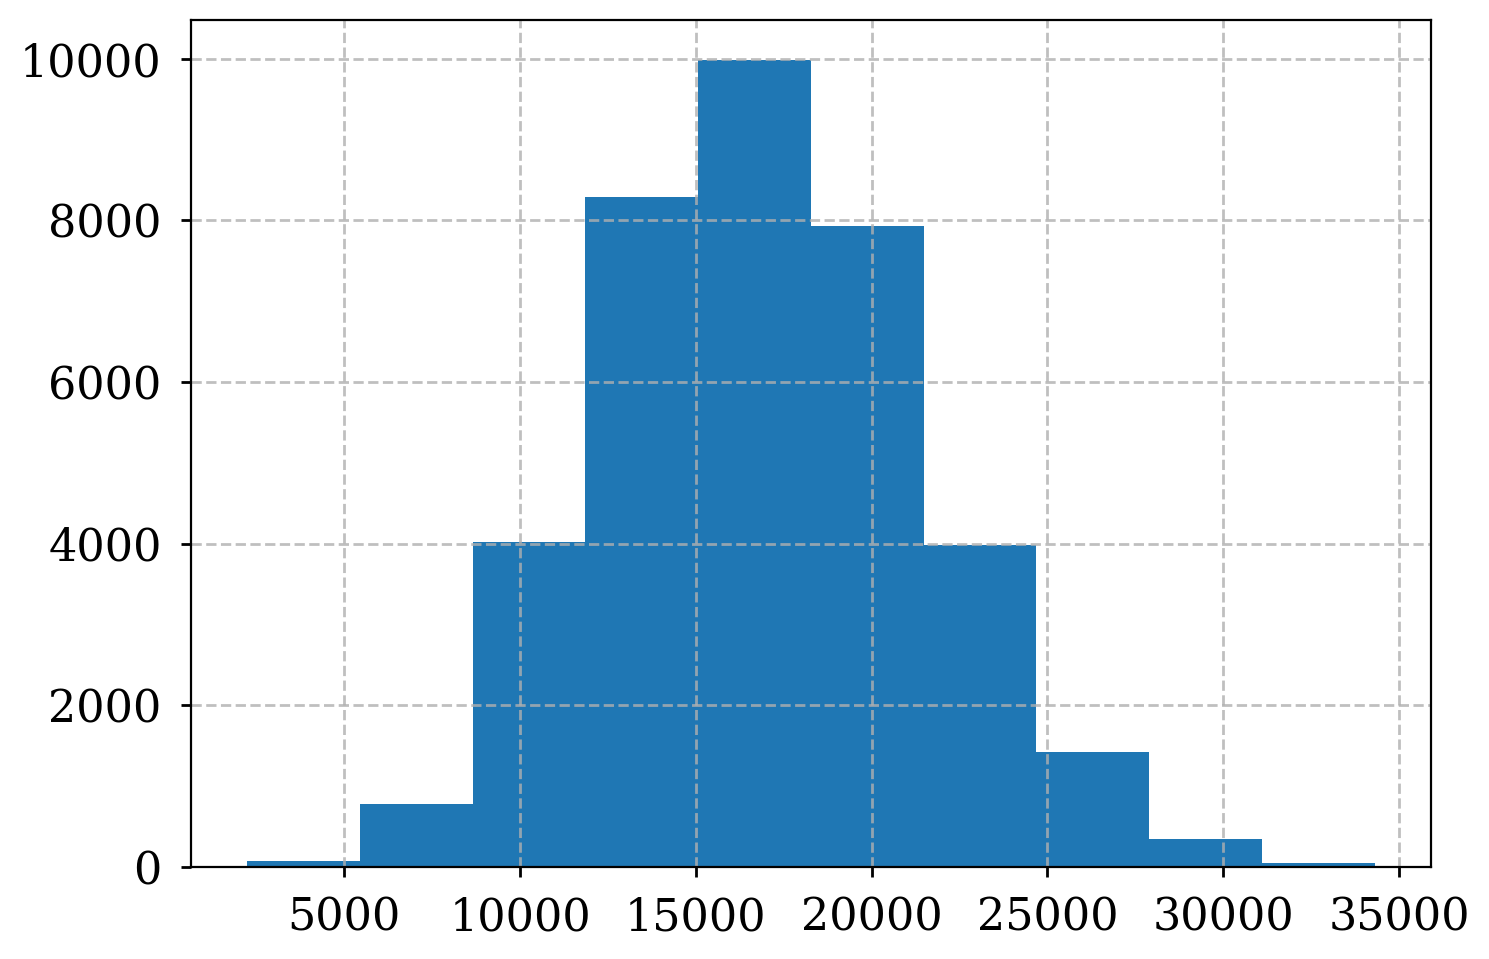

In [81]:
plt.hist(Y_us)

In [82]:
Si = sobol.analyze(problem, Y_us)

In [85]:
total_Si, first_Si, second_Si = Si.to_df()

In [86]:
from SALib.plotting.bar import plot as barplot

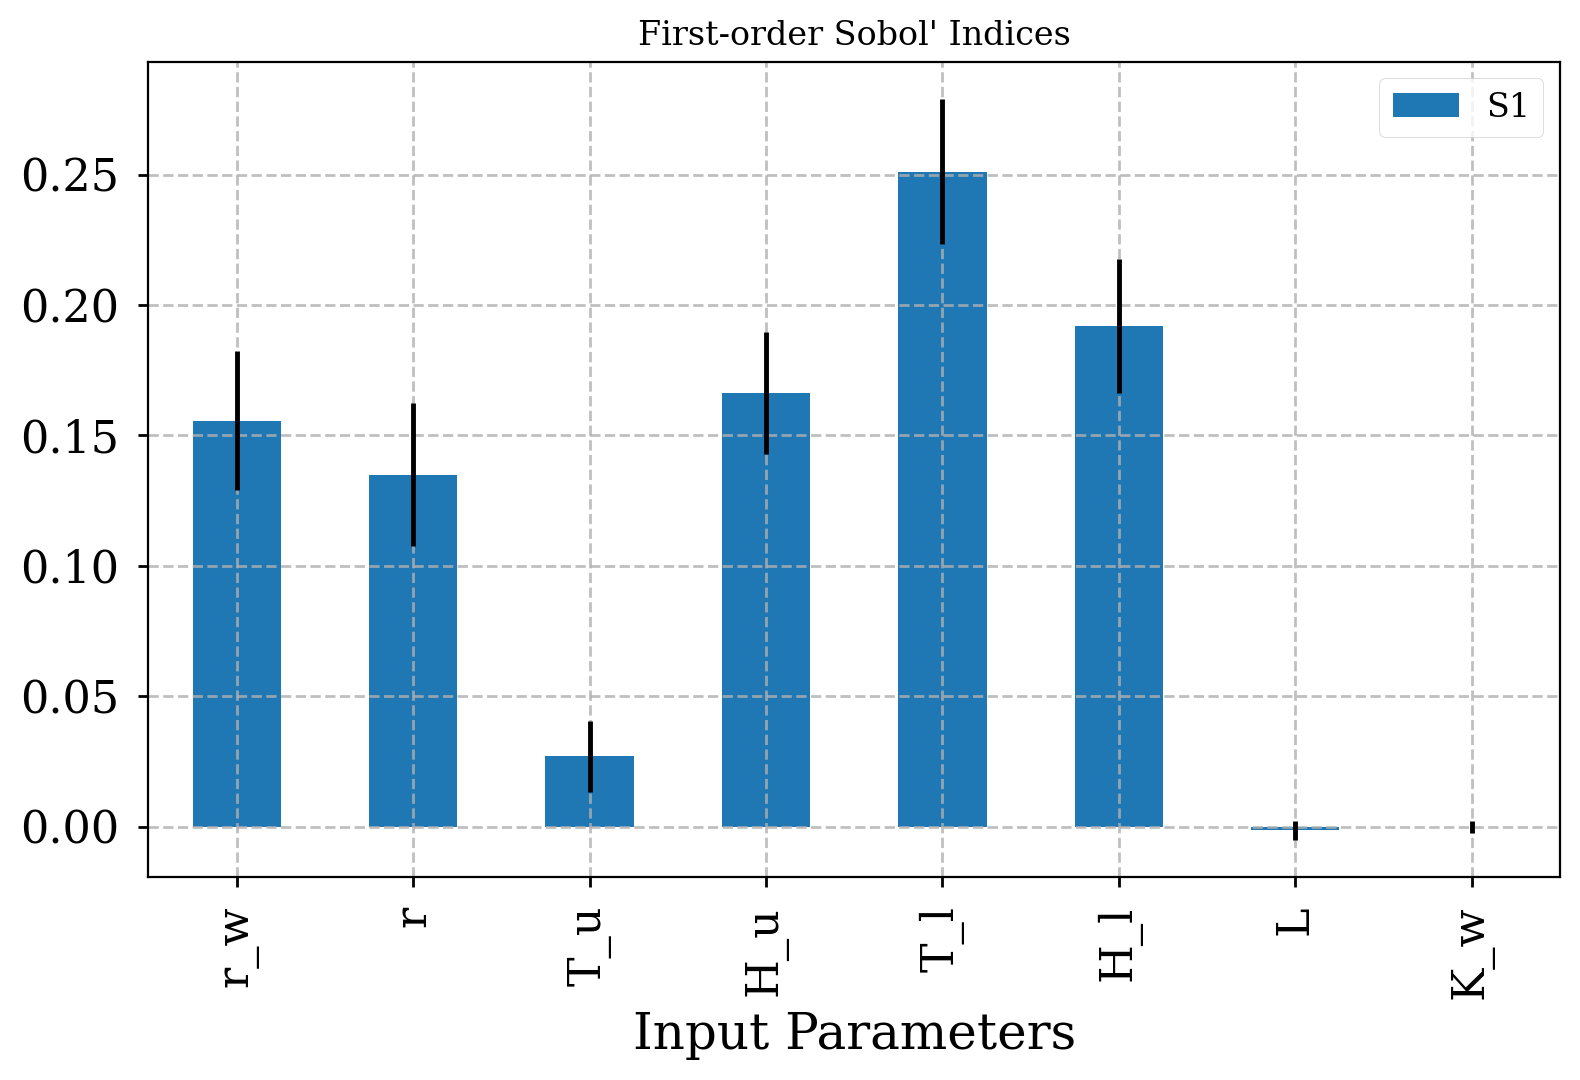

In [87]:
ax_si = barplot(first_Si)
ax_si.set_xlabel("Input Parameters")
ax_si.set_title("First-order Sobol' Indices")
plt.tight_layout()
plt.savefig("Borehole_main_nn.png", dpi=200)

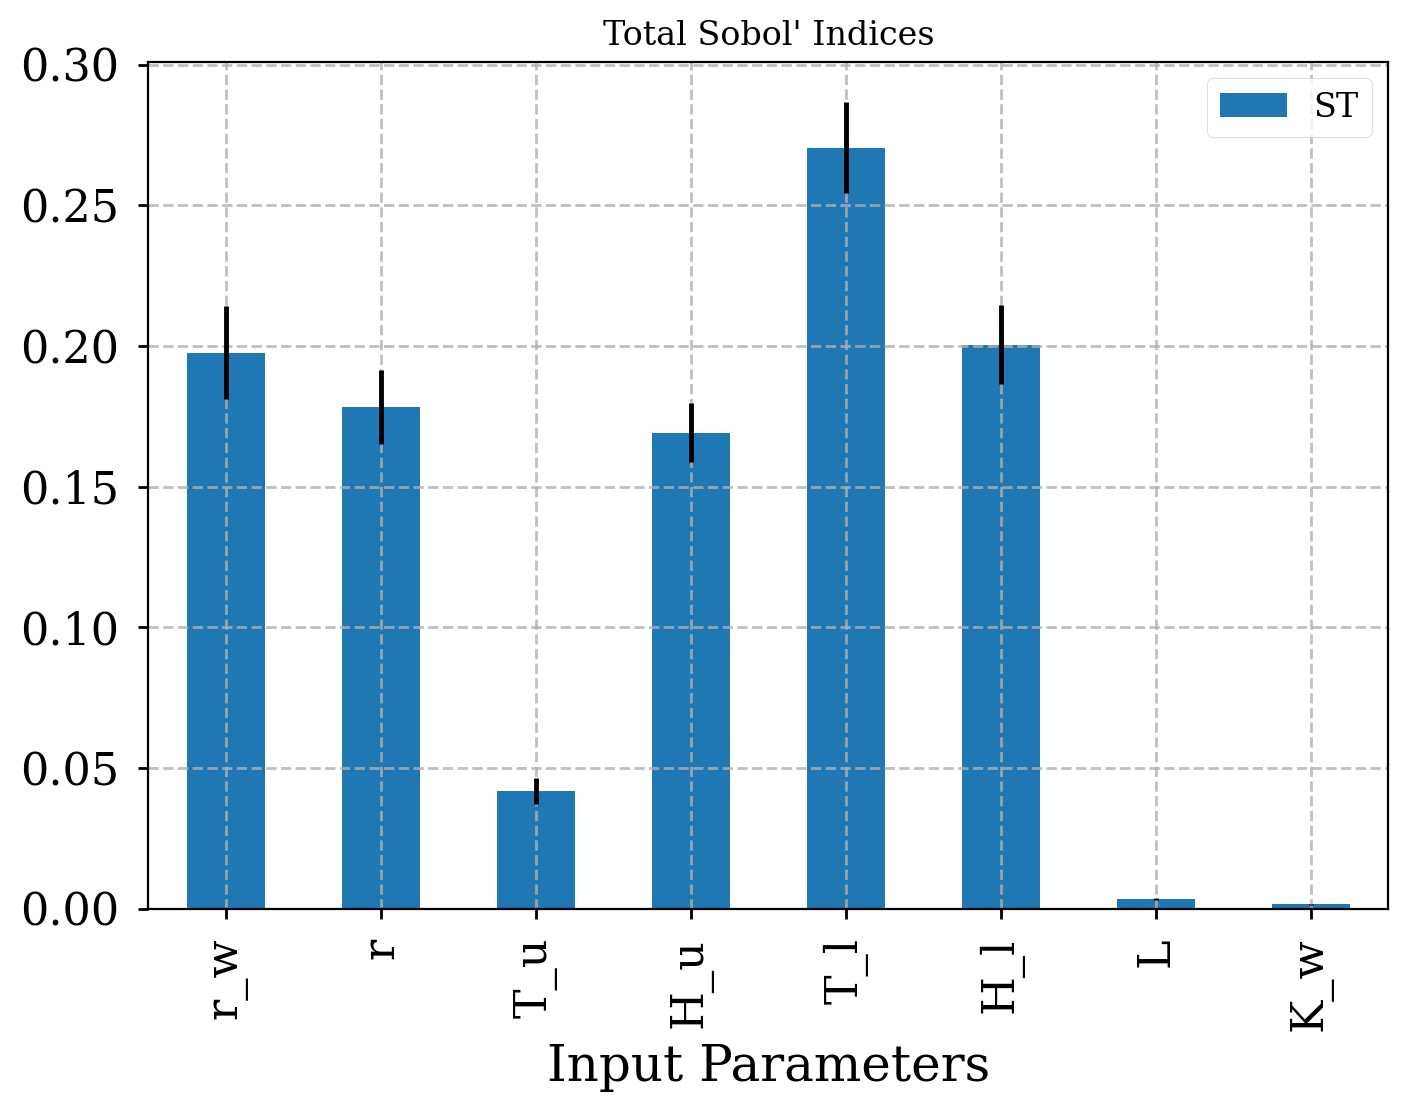

In [88]:
ax_st = barplot(total_Si)
ax_st.set_xlabel("Input Parameters")
ax_st.set_title("Total Sobol' Indices")
plt.savefig("Borehole_total_nn.png", dpi=200)